In [1]:
import sys
import xarray as xr
import numpy as np
import pandas as pd
import math
import glob
import yaml
import cartopy
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colorbar import Colorbar # different way to handle colorbar
import matplotlib.ticker as mticker
import cmocean.cm as cmo
import seaborn as sns

# cartopy
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes
import cartopy.feature as cfeature
import dask

# import personal modules
# Path to modules
sys.path.append('../modules')
# Import my modules
from utils import roundPartial, select_months_ds
from plotter import draw_basemap, plot_terrain, plot_arscale_cbar
from colorline import colorline
from trajectory_post_funcs import calculate_heatmaps_from_trajectories
import customcmaps as ccmaps

dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
path_to_data = '/expanse/nfs/cw3e/cwp140/'
path_to_out  = '../out/'       # output files (numerical results, intermediate datafiles) -- read & write
path_to_figs = '../figs/'      # figures

In [3]:
start_mon = 11
end_mon = 4
## load PRISM watershed precip dataset to get list of HUC8s
fname = path_to_data + 'preprocessed/PRISM/PRISM_HUC8_CO_sp.nc'
PRISM = xr.open_dataset(fname)
## add water year to data as coordinate
water_year = (PRISM.date.dt.month >= 10) + PRISM.date.dt.year
PRISM.coords['water_year'] = water_year
HUC8_ID_lst = PRISM.HUC8.values ## get list of HUC8 IDs
PRISM = select_months_ds(PRISM, start_mon, end_mon, 'date')

# ## subset to ssn
# PRISM = select_months_ds(PRISM, start_mon, end_mon, 'date')
## for each HUC8, what is the total WY precipitation?
PRISM_WY = PRISM.prec.groupby(PRISM.water_year).sum(dim="date").sum('water_year')
PRISM_WY


## for each HUC8, what is the total WY top-decile precipitation?
PRISM_90 = PRISM.where(PRISM.extreme == 1, drop=True)
PRISM_90WY = PRISM_90.prec.groupby(PRISM_90.water_year).sum(dim="date").mean('water_year')
PRISM_90WY

<xarray.DataArray 'prec' (HUC8: 92)>
array([39.217612 , 21.36802  , 40.258452 , 50.318008 , 27.018384 ,
       81.4394   , 29.766136 , 40.169992 , 15.766092 ,  9.388456 ,
       30.580852 , 10.09158  , 20.562908 , 19.57922  , 25.270496 ,
       21.659552 , 24.447692 , 30.125356 ,  9.4599696, 39.22478  ,
       70.36992  , 35.052968 , 55.396196 , 24.478904 , 25.8685   ,
       23.10666  , 41.49454  , 33.8260664, 20.7705   , 22.06782  ,
       23.901844 , 30.197072 , 12.681064 , 17.85902  , 31.215428 ,
       16.432112 , 12.3124808, 15.065728 , 87.06332  , 20.3028404,
       16.865452 , 21.65632  , 50.9318452, 33.328408 , 23.542368 ,
       24.793624 , 22.461272 , 26.806288 , 24.650442 , 34.5948108,
       86.129496 , 58.942452 , 55.293236 , 24.882272 , 17.172996 ,
       34.518128 , 26.130568 , 26.243148 , 25.839164 , 36.42128  ,
       29.345024 , 37.855452 , 28.626012 , 29.073864 , 10.982344 ,
       99.923324 , 41.6511888, 77.239228 , 20.677044 , 24.77494  ,
       35.716272 , 94.316316 , 50.686808 , 66.2904   , 35.9911916,
       18.8353192, 13.601304 , 54.862184 , 41.960912 , 12.78586  ,
       27.302068 , 20.785664 , 24.155596 , 47.670496 , 34.55128  ,
       26.768132 , 86.344696 , 45.280816 , 16.819924 , 24.721348 ,
       27.111356 , 27.222208 ])
Coordinates:
  * HUC8     (HUC8) <U8 '14080107' '14080105' ... '11030001' '10250013'

In [4]:
## use tARgetv4 AR dt for identifying AR at coast
varname = 'tARget'
thres = 0


In [5]:
def calculate_WY_contribution(PRISM, HUC8_ID):
    PRISM = PRISM.sel(HUC8=HUC8_ID)
    
    fname = path_to_data + '/preprocessed/ERA5_trajectories/combined_extreme_AR/PRISM_HUC8_{0}.nc'.format(HUC8_ID)
    ds = xr.open_dataset(fname)
    ds['ar_scale'] = ds.ar_scale.fillna(0)
    ds = select_months_ds(ds, start_mon, end_mon, 'start_date')
    
    ## calculate the total top-decile precipitation in each WY
    extreme_days = PRISM.where(PRISM.extreme > 0, drop=True).date.values
    ext_prec = PRISM.sel(date = extreme_days)
    extreme_prec = ext_prec.prec.groupby(ext_prec.water_year).sum(dim="date")

    extreme_prec = extreme_prec.to_dataframe()
    extreme_prec = extreme_prec.rename(columns={"prec": "Total Precipitation"})
    
    ## calculate the AR-related top-decile prec
    extreme_AR = ds.sel(start_date = extreme_days)
    extreme_AR = extreme_AR.where(extreme_AR[varname] > thres, drop=True).start_date.values
    
    ## select those dates from the PRISM dataset
    tmp = PRISM.sel(date=extreme_AR)
    ## convert to pandas df
    tmp = tmp.prec.to_dataframe()
    
    extreme_ar_prec = tmp.groupby(["water_year"], dropna=False).sum("date")
    extreme_ar_prec = extreme_ar_prec.rename(columns={"prec": "AR Associated"})
    
    ## calculate the total contribution fraction
    # extreme_contr = (extreme_ar_prec / extreme_prec)*100
    
    ## put into a dataframe
    df = pd.concat([extreme_prec, extreme_ar_prec], axis=1)
    # df = pd.DataFrame({'Total Precipitation': extreme_prec.values,
    #                    'AR Associated': extreme_ar_prec.prec.values},
    #                   index=extreme_prec.water_year.values)

    df['Percent'] = (df['AR Associated']/df['Total Precipitation'])*100
    
    return df

In [6]:
# HUC8_ID_lst = ['14050001', '13010001', '10190002', '11020001']
# HUC8_lbl_lst = ['Upper Yampa', 'Rio Grande Headwaters', 'Upper South Platte', 'Arkansas Headwaters']
HUC8_ID_lst = ['14050001', '14010004', '14020002', '14080101']
HUC8_lbl_lst = ['Upper Yampa', 'Roaring Fork', 'Upper Gunnison', 'Upper San Juan']
df_lst = []
for i, HUC8ID in enumerate(HUC8_ID_lst):
    df = calculate_WY_contribution(PRISM, HUC8ID)
    df['wy_str'] = df.index.astype(str).str[-2:]
    df_lst.append(df)

In [7]:
df_lst[-1]

,HUC8,Total Precipitation,AR Associated,Percent,wy_str
water_year,,,,,
2000,14080101,30.5743,NaN,NaN,00
2003,14080101,49.8024,49.8024,100.000000,03
2004,14080101,75.7876,NaN,NaN,04
2005,14080101,139.2243,89.3423,64.171484,05
2008,14080101,188.0531,160.2086,85.193278,08
2009,14080101,71.5957,30.6023,42.743209,09
2010,14080101,75.2630,33.5086,44.522009,10
2011,14080101,46.9155,16.2421,34.619902,11
2012,14080101,14.3292,NaN,NaN,12


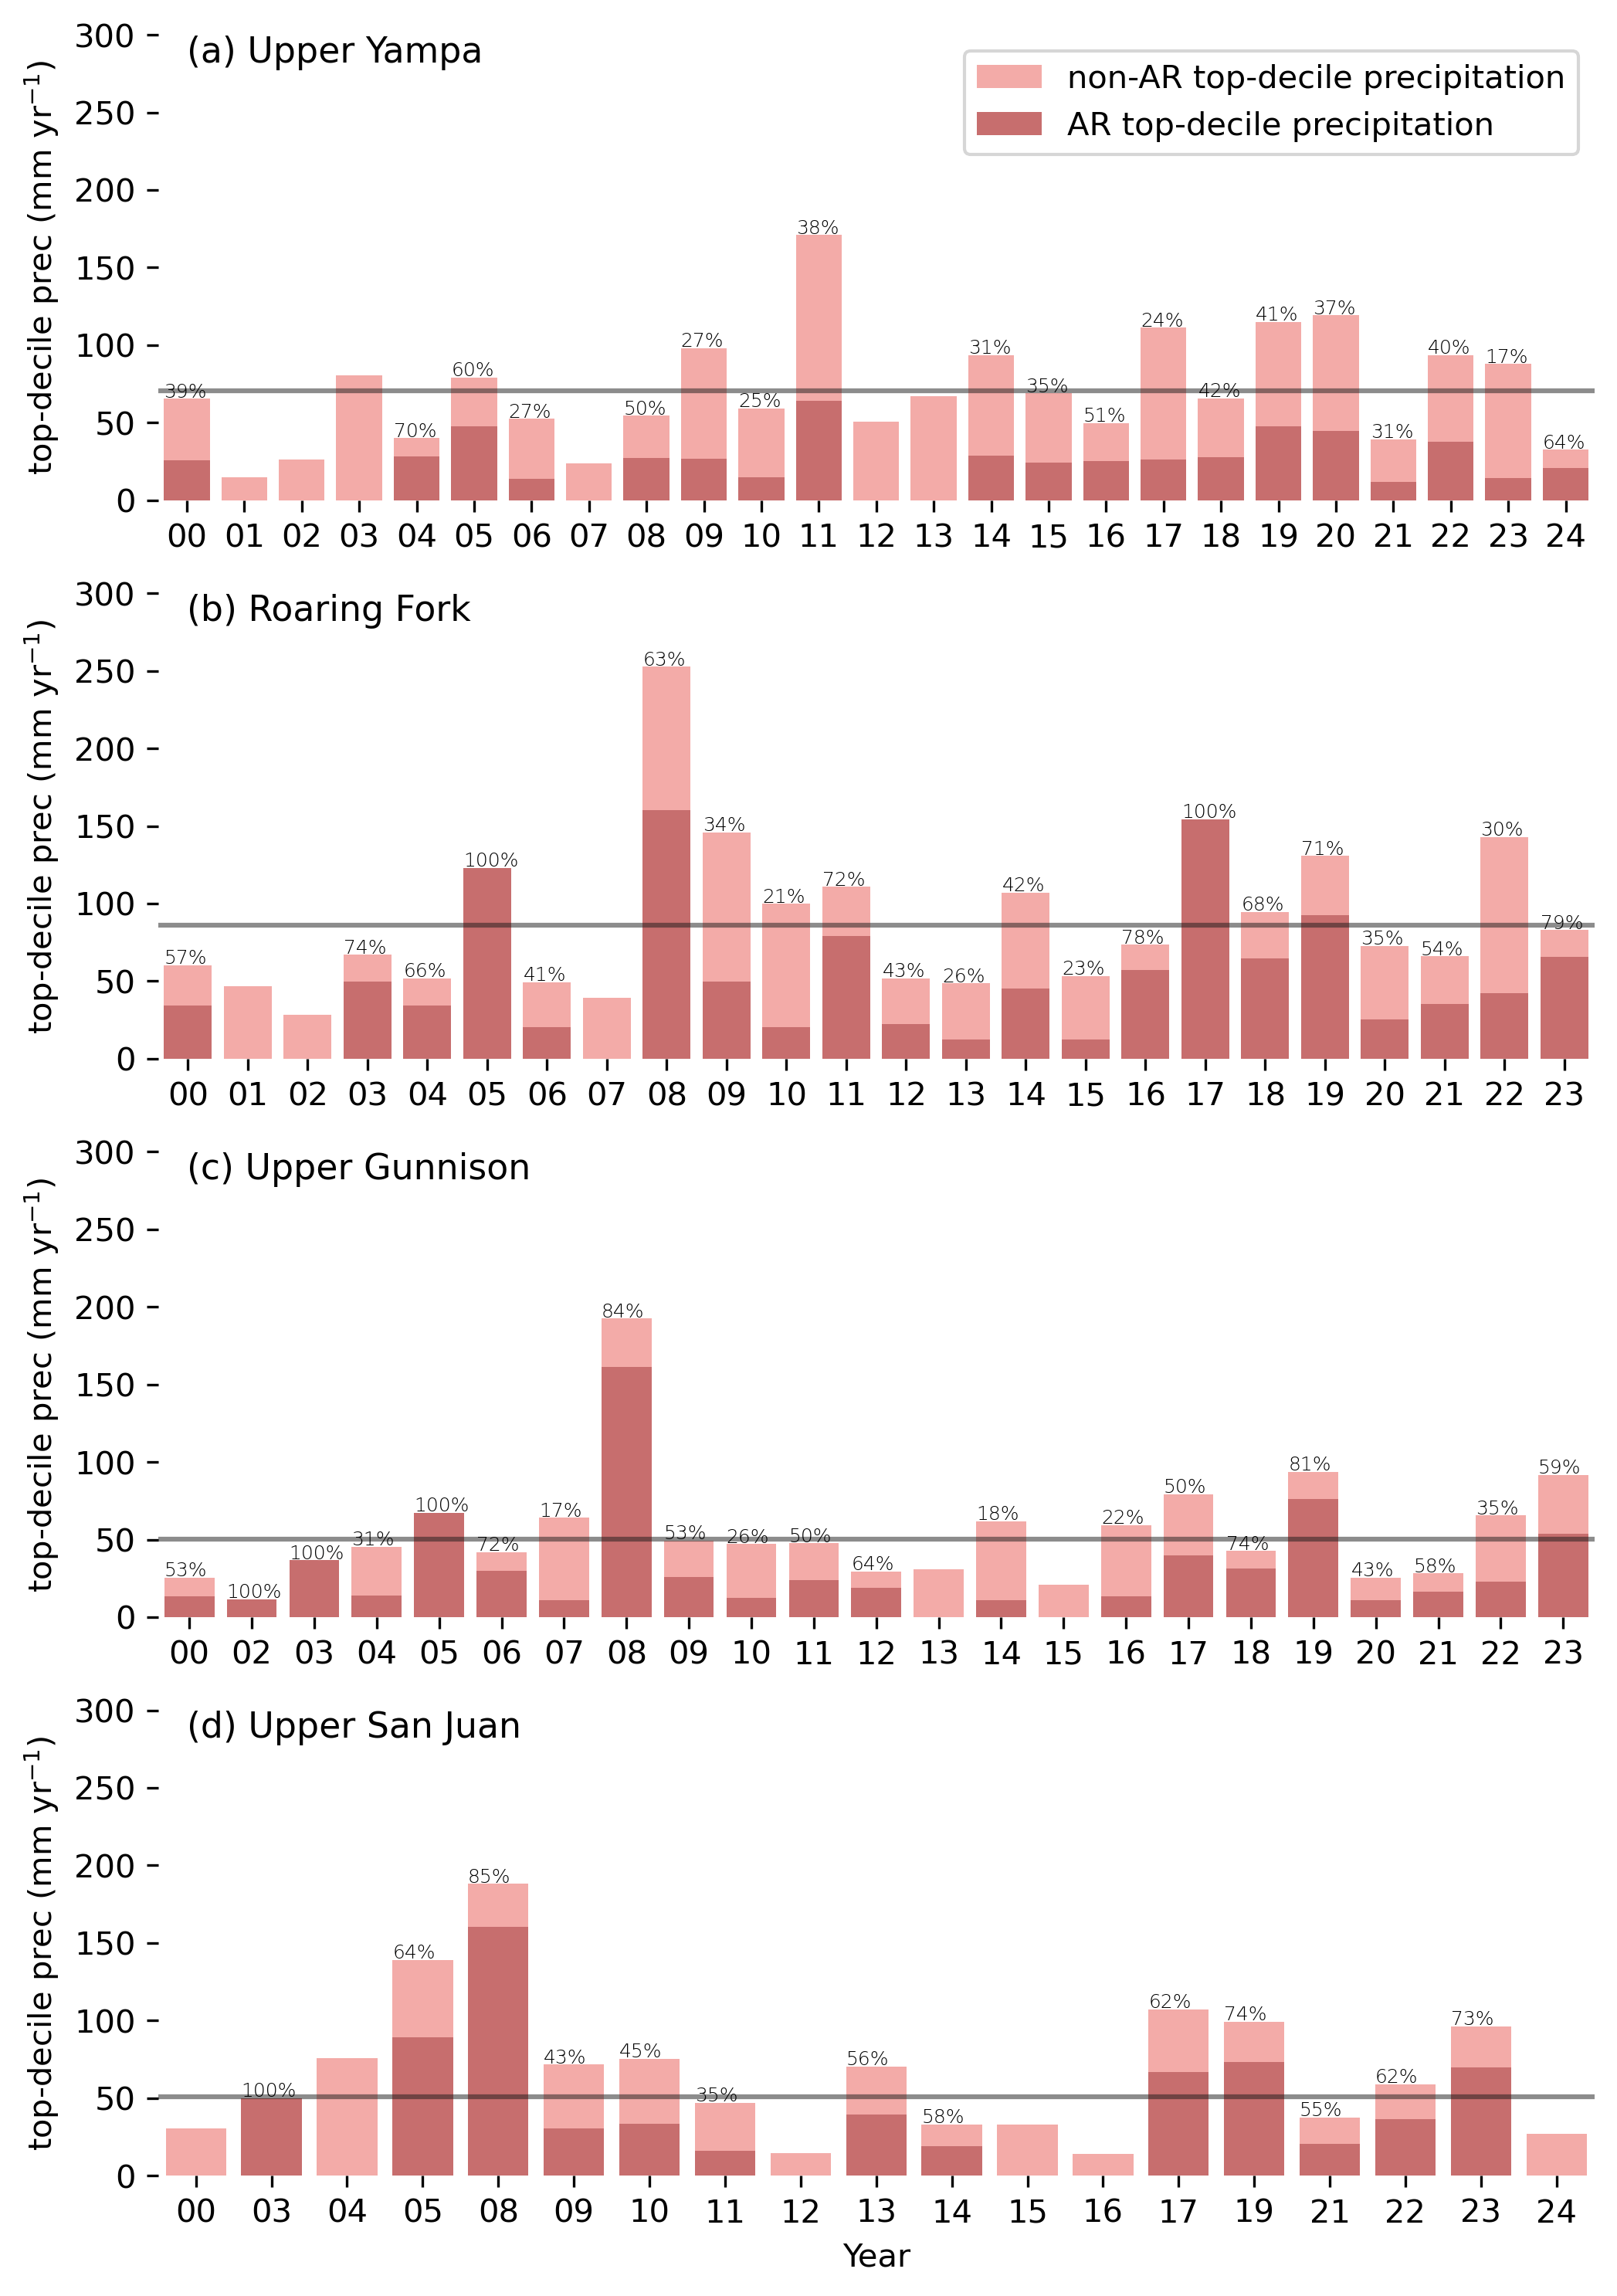

In [8]:
# list of letters to append to titles
letter_lst = list(map(chr, range(97, 123)))
fig = plt.figure(figsize=(8,12))
fig.dpi = 300
fname = '../figs/time_series_extreme_NDJFMA'
fmt1 = 'png'

nrows = 4
ncols = 1
gs = fig.add_gridspec(nrows, ncols)
color_list = ['b', 'r', 'g']

for k, df in enumerate(df_lst):
    ## Initialize the matplotlib figure
    ax = fig.add_subplot(gs[k, 0])
    
    # Plot the total precip
    sns.set_color_codes("pastel")
    d1 = sns.barplot(x="wy_str", y="Total Precipitation", data=df, color='r', label="non-AR top-decile precipitation")
    
    # Plot the precipitation where ARs were involved
    sns.set_color_codes("muted")
    d2 = sns.barplot(x="wy_str", y="AR Associated", data=df, color='r', label="AR top-decile precipitation")
    
    # Add a legend and informative axis label
    ax.set(ylim=(0, 300), ylabel="top-decile prec (mm yr$^{-1}$)", xlabel="")
    sns.despine(left=True, bottom=True)
    #     ax.set_title(subtitles[i])

    # ## add min/max/mean/median lines
    # ax.axhline(y=df['AR Associated'].min(), color='k', linestyle=':')
    # ax.axhline(y=df['AR Associated'].max(), color='k', linestyle=':') 
    # ax.axhline(y=df['AR Associated'].mean(), color='k', linestyle='-')

    ## add average WY top-decile precipitation
    ax.axhline(y=PRISM_90WY.sel(HUC8=HUC8_ID_lst[k]).values, color='k', linestyle='-', zorder=1, alpha=0.5)

    yloc = df['Total Precipitation'].values
    xloc = np.arange(0, len(df), 1)
    proportion = df['Percent'].values
    for i, (x, prop) in enumerate(zip(xloc, proportion)):
        if prop > 0:
            plt.text(x=x-0.4,
                     y=yloc[i]+1,
                     s=f'{int(np.round(prop, 0))}%',
                     color="black",
                     fontsize=6,
                     fontweight="light", zorder=200)
    
    
    if k == 0:
        ax.legend(ncol=1, loc="upper right", frameon=True)
    else:
        ax.get_legend().remove()
    
    if k == 3:
        ax.set(xlabel="Year")
    else:
        # ax.tick_params(labelbottom=False)
        pass
    # d1.set_xticklabels(d1.get_xticklabels(), rotation=45)

    titlestring = '({0}) {1}'.format(letter_lst[k], HUC8_lbl_lst[k])
    ax.text(0.02, 1., titlestring, ha='left', va='top', transform=ax.transAxes, fontsize=11., backgroundcolor='white', zorder=101)

    
fig.savefig('%s.%s' %(fname, fmt1), bbox_inches='tight', dpi=fig.dpi)
plt.show()